# patch_size를 1,3,5,7,9,11로 바꾸어 가면서 테스트 해 보자

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim
import rasterio
import copy
import torch.nn.init as init

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### train 함수, evaluate 함수

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = model.state_dict()  # 초기 모델 가중치 저장
    no_improve_count = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)  # 배치별 loss * 개수로 전체 손실 계산
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)  # 전체 샘플 수로 나눔
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"\nEpoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%\n")

        # Early Stopping & Model Saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break
    
    return best_model_state, train_losses, val_losses

In [4]:
target_name_mapping = {
    0: "Non-Forest", #비산림
    1: "Pine", #소나무
    2: "Nut Pine", #잣나무
    3: "Larch", #낙엽송
    4: "Mongolian Oak", #신갈나무
    5: "Oriental Oak" #굴참나무
}

def evaluate_model_with_cm(model, val_loader, num_classes=6, target_name_mapping=target_name_mapping):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  
            all_predictions.extend(predicted.cpu().numpy())  

    # 모든 클래스 목록 (0 ~ num_classes-1)
    full_class_labels = np.arange(num_classes)

    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=full_class_labels)

    # Confusion Matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_name_mapping.values(), yticklabels=target_name_mapping.values())
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Classification Report
    target_names = list(target_name_mapping.values())
    report = classification_report(all_labels, all_predictions, labels=full_class_labels, target_names=target_names, digits=3)

    print("Classification Report:")
    print(report)


### dataset 클래스 정의

In [5]:
class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=3, box_filter_fn=None, transform=None):
        """
        Args:
            large_tif_dir (str): 여러 개의 큰 TIFF 파일이 저장된 디렉토리 경로.
            file_list (list of str): 처리할 원천 데이터 파일명 리스트.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 ("file", "x_pos", "y_pos", "label" 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (항상 홀수여야 함).
            box_filter_fn (callable, optional): 박스 번호 필터링 함수.
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        if patch_size % 2 == 0:
            raise ValueError("patch_size는 홀수여야 합니다.")

        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        # 박스 필터 함수 설정 (기본값: 모든 박스 사용)
        self.box_filter_fn = box_filter_fn or (lambda box_number: True)

        # 파일명 필터링: file_list에 있는 파일만 유지
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)

        # 박스 번호 필터링
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.half_size = patch_size // 2  # 패치의 반 크기
        self.transform = transform

        # 각 파일명을 키로 하고 이미지를 값으로 가지는 딕셔너리
        self.image_cache = {}

    def _load_image(self, file_name):
        """파일 이름에 해당하는 이미지를 로드하여 캐시에 저장."""
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 현재 인덱스에 해당하는 데이터 가져오기
        row = self.label_df.iloc[idx]
        file_name = row["file"]
        x, y = row["x_pos"], row["y_pos"]
        label = row["label"]

        # 이미지 로드
        image = self._load_image(file_name)
        image_height, image_width = image.shape[:2]

        # 중심 좌표 기준으로 패치의 좌상단 좌표 계산
        x_start = x - self.half_size
        y_start = y - self.half_size
        x_end = x + self.half_size + 1  # 슬라이싱할 범위는 [start:end]
        y_end = y + self.half_size + 1

        # 범위 검사
        if x_start < 0 or y_start < 0 or x_end > image_width or y_end > image_height:
            raise ValueError(f"Patch centered at (x={x}, y={y}) exceeds bounds of image '{file_name}'.")

        # 이미지 슬라이싱
        patch = image[y_start:y_end, x_start:x_end]

        # 전처리 적용
        if self.transform:
            patch = self.transform(patch)

        return patch, label


In [10]:
import os
import pandas as pd
import tifffile as tiff
from torch.utils.data import Dataset

class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=3, box_filter_fn=None, transform=None):
        if patch_size % 2 == 0:
            raise ValueError("patch_size는 홀수여야 합니다.")

        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        self.box_filter_fn = box_filter_fn or (lambda box_number: True)
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.half_size = patch_size // 2
        self.transform = transform

        self.image_cache = {}

        # 유효한 샘플만 남긴 인덱스 리스트
        self.valid_indices = self._filter_valid_indices()

    def _load_image(self, file_name):
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def _filter_valid_indices(self):
        """이미지 경계를 벗어나지 않는 유효한 인덱스만 저장"""
        valid_indices = []
        for idx, row in self.label_df.iterrows():
            file_name = row["file"]
            x, y = row["x_pos"], row["y_pos"]

            # 이미지 크기 확인
            try:
                image = self._load_image(file_name)
                image_height, image_width = image.shape[:2]

                x_start, y_start = x - self.half_size, y - self.half_size
                x_end, y_end = x + self.half_size + 1, y + self.half_size + 1

                # 이미지 범위를 벗어나지 않는 경우만 유효한 인덱스로 저장
                if 0 <= x_start and 0 <= y_start and x_end <= image_width and y_end <= image_height:
                    valid_indices.append(idx)
            except FileNotFoundError:
                continue  # 파일이 없으면 스킵

        return valid_indices

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        row = self.label_df.iloc[self.valid_indices[idx]]
        file_name, x, y, label = row["file"], row["x_pos"], row["y_pos"], row["label"]

        image = self._load_image(file_name)
        x_start, y_start = x - self.half_size, y - self.half_size
        x_end, y_end = x + self.half_size + 1, y + self.half_size + 1

        patch = image[y_start:y_end, x_start:x_end]

        if self.transform:
            patch = self.transform(patch)

        return patch, label


### 테스트 지역 선별  

In [6]:
test_filter = lambda box_number: (box_number % 9 == 0 or box_number % 9 == 5)

### resnet과 같은 구조의 모델

In [7]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

class ResNetLike(nn.Module):
    def __init__(self, num_classes=6, patch_size=1):
        super(ResNetLike, self).__init__()
        self.in_channels = 64
        self.patch_size = patch_size
        
        # 입력 크기에 맞게 조정 (48, patch_size, patch_size)
        self.conv1 = nn.Conv2d(48, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=1)
        self.layer3 = self._make_layer(256, 2, stride=1)
        
        # AdaptiveAvgPool 크기 조정
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
    
    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


### 데이터 준비함수, 학습 평가 함수 정의

In [11]:
# 이미지 전처리 (Naive)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
])

# 데이터셋 생성 함수
def create_datasets(patch_size):
    dataset_kwargs = {
        "large_tif_dir": r"C:\\Users\\taebin\\Desktop\\my_study\\capstone_design\\data3\\원천 데이터\\naive",
        "file_list": ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"],
        "label_file": r"C:\\Users\\taebin\\Desktop\\my_study\\capstone_design\\data3\\라벨링 데이터\\label_mapping_sampled_5.csv",
        "patch_size": patch_size,
        "transform": transform
    }
    return (
        TiffDataset(**dataset_kwargs, box_filter_fn=lambda box_number: not test_filter(box_number)),  # train
        TiffDataset(**dataset_kwargs, box_filter_fn=test_filter)  # val
    )

# 데이터로더 생성 함수
def create_dataloaders(train_dataset, val_dataset, batch_size=32, num_workers=0):
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    )

# 학습 및 평가 함수
def train_and_evaluate(patch_size, train_loader, val_loader, num_epochs=30):
    print(f"Training with patch size: {patch_size}")

    model = ResNetLike(num_classes=6).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_model_state, train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs, patience=100
    )
    
    torch.save(best_model_state, f"patch_size_test_{patch_size}_{num_epochs}.pth")
    model.load_state_dict(best_model_state)
    
    print("train data")
    evaluate_model_with_cm(model, train_loader, num_classes=6)
    print("validation data")
    evaluate_model_with_cm(model, val_loader, num_classes=6)


### 패치사이즈를 바꾸어가며 테스트

Training with patch size: 1


Epoch 1/15 - Validation: 100%|██████████| 1163/1163 [00:24<00:00, 47.29it/s]



Epoch [1/15], Train Loss: 0.5695, Train Accuracy: 78.65%, Val Loss: 0.7140, Val Accuracy: 71.52%



Epoch 2/15 - Validation: 100%|██████████| 1163/1163 [00:21<00:00, 53.89it/s]



Epoch [2/15], Train Loss: 0.4433, Train Accuracy: 83.44%, Val Loss: 0.5982, Val Accuracy: 78.69%



...

Epoch 14/15 - Validation: 100%|██████████| 1163/1163 [00:17<00:00, 65.98it/s]



Epoch [14/15], Train Loss: 0.2815, Train Accuracy: 89.63%, Val Loss: 0.5735, Val Accuracy: 81.16%



Epoch 15/15 - Validation: 100%|██████████| 1163/1163 [00:18<00:00, 61.91it/s]



Epoch [15/15], Train Loss: 0.2749, Train Accuracy: 89.80%, Val Loss: 0.5000, Val Accuracy: 83.08%

train data


Evaluation Progress: 100%|██████████| 3683/3683 [00:56<00:00, 64.81it/s]


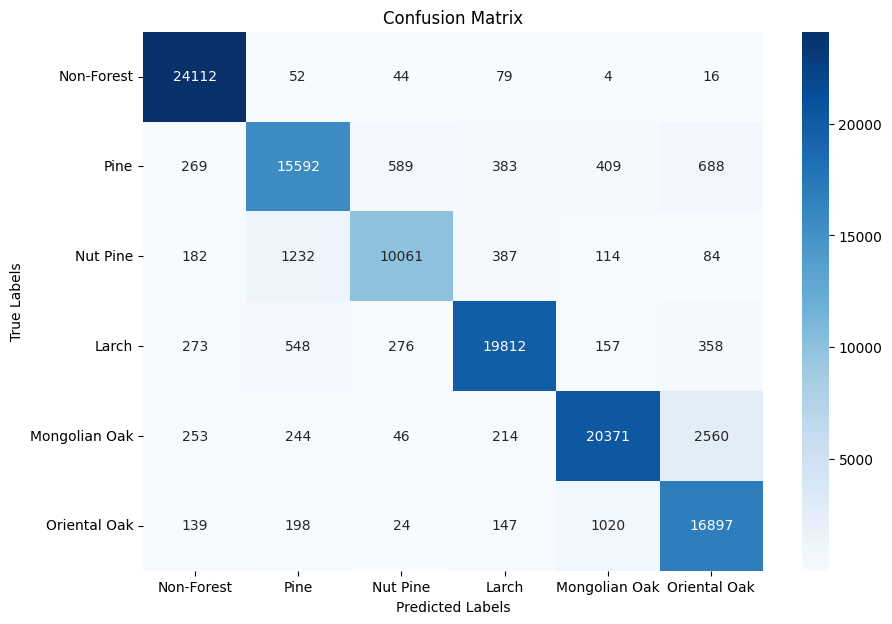

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.956     0.992     0.974     24307
         Pine      0.873     0.870     0.871     17930
     Nut Pine      0.911     0.834     0.871     12060
        Larch      0.942     0.925     0.934     21424
Mongolian Oak      0.923     0.860     0.890     23688
 Oriental Oak      0.820     0.917     0.866     18425

     accuracy                          0.907    117834
    macro avg      0.904     0.900     0.901    117834
 weighted avg      0.908     0.907     0.907    117834

validation data


Evaluation Progress: 100%|██████████| 1163/1163 [00:16<00:00, 68.70it/s]


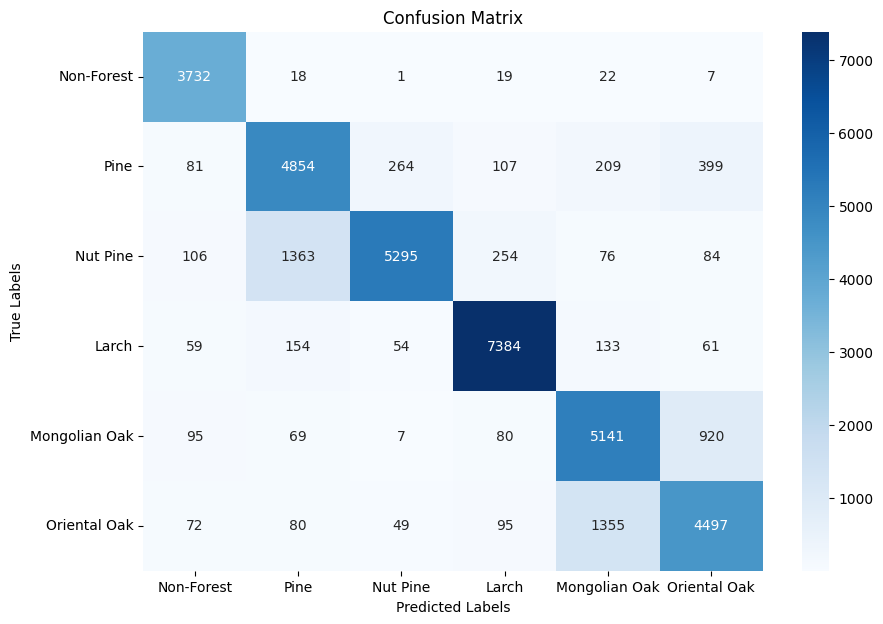

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.900     0.982     0.940      3799
         Pine      0.742     0.821     0.780      5914
     Nut Pine      0.934     0.738     0.824      7178
        Larch      0.930     0.941     0.936      7845
Mongolian Oak      0.741     0.814     0.776      6312
 Oriental Oak      0.754     0.731     0.742      6148

     accuracy                          0.831     37196
    macro avg      0.834     0.838     0.833     37196
 weighted avg      0.837     0.831     0.831     37196

Training with patch size: 3


Epoch 1/15 - Validation: 100%|██████████| 1163/1163 [00:29<00:00, 39.82it/s]



Epoch [1/15], Train Loss: 0.5491, Train Accuracy: 78.70%, Val Loss: 0.5051, Val Accuracy: 81.89%



Epoch 2/15 - Validation: 100%|██████████| 1163/1163 [00:28<00:00, 40.92it/s]



Epoch [2/15], Train Loss: 0.4268, Train Accuracy: 84.00%, Val Loss: 0.5600, Val Accuracy: 81.31%



...

Epoch 14/15 - Validation: 100%|██████████| 1163/1163 [00:27<00:00, 41.71it/s]



Epoch [14/15], Train Loss: 0.2295, Train Accuracy: 91.58%, Val Loss: 0.5267, Val Accuracy: 85.57%



Epoch 15/15 - Validation: 100%|██████████| 1163/1163 [00:26<00:00, 43.58it/s]



Epoch [15/15], Train Loss: 0.2209, Train Accuracy: 91.85%, Val Loss: 0.5994, Val Accuracy: 84.40%

train data


Evaluation Progress: 100%|██████████| 3683/3683 [01:24<00:00, 43.64it/s]


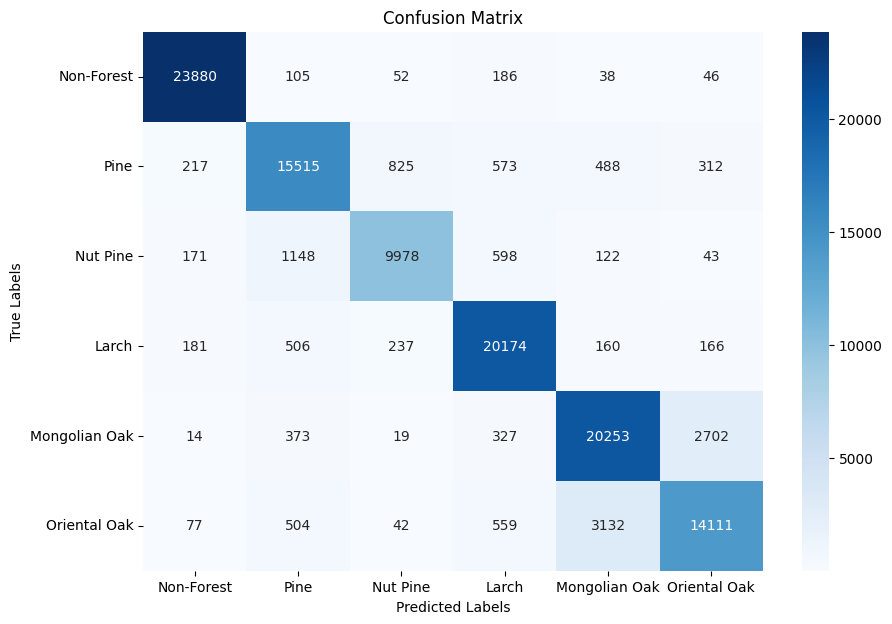

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.973     0.982     0.978     24307
         Pine      0.855     0.865     0.860     17930
     Nut Pine      0.895     0.827     0.860     12060
        Larch      0.900     0.942     0.920     21424
Mongolian Oak      0.837     0.855     0.846     23688
 Oriental Oak      0.812     0.766     0.788     18425

     accuracy                          0.882    117834
    macro avg      0.879     0.873     0.875    117834
 weighted avg      0.881     0.882     0.881    117834

validation data


Evaluation Progress: 100%|██████████| 1163/1163 [00:26<00:00, 43.98it/s]


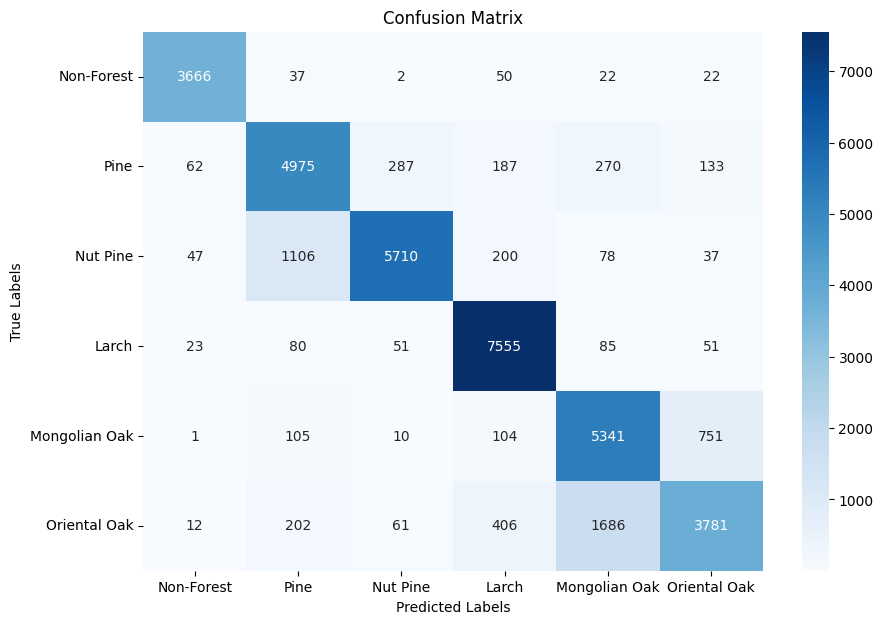

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.962     0.965     0.963      3799
         Pine      0.765     0.841     0.801      5914
     Nut Pine      0.933     0.795     0.859      7178
        Larch      0.889     0.963     0.924      7845
Mongolian Oak      0.714     0.846     0.774      6312
 Oriental Oak      0.792     0.615     0.692      6148

     accuracy                          0.834     37196
    macro avg      0.842     0.838     0.836     37196
 weighted avg      0.839     0.834     0.832     37196

Training with patch size: 5


Epoch 1/15 - Training:   0%|          | 1/3683 [00:01<1:41:54,  1.66s/it]


ValueError: Patch centered at (x=1801, y=2998) exceeds bounds of image 'jiri_2.tif'.

In [9]:
patch_sizes = [1, 3, 5, 7, 9, 11]

# 전체 실행
for patch_size in patch_sizes:
    train_dataset, val_dataset = create_datasets(patch_size)
    train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)
    train_and_evaluate(patch_size, train_loader, val_loader, num_epochs=15)

Training with patch size: 5


Epoch 1/15 - Validation: 100%|██████████| 1159/1159 [00:43<00:00, 26.41it/s]



Epoch [1/15], Train Loss: 0.5159, Train Accuracy: 80.41%, Val Loss: 0.7662, Val Accuracy: 72.17%



Epoch 2/15 - Validation: 100%|██████████| 1159/1159 [00:45<00:00, 25.55it/s]



Epoch [2/15], Train Loss: 0.4008, Train Accuracy: 85.00%, Val Loss: 0.5767, Val Accuracy: 79.65%



...

Epoch 14/15 - Validation: 100%|██████████| 1159/1159 [00:42<00:00, 27.25it/s]



Epoch [14/15], Train Loss: 0.1952, Train Accuracy: 92.85%, Val Loss: 0.5111, Val Accuracy: 85.13%



Epoch 15/15 - Validation: 100%|██████████| 1159/1159 [00:41<00:00, 27.62it/s]



Epoch [15/15], Train Loss: 0.1906, Train Accuracy: 92.98%, Val Loss: 0.5841, Val Accuracy: 83.87%

train data


Evaluation Progress: 100%|██████████| 3662/3662 [02:10<00:00, 28.11it/s]


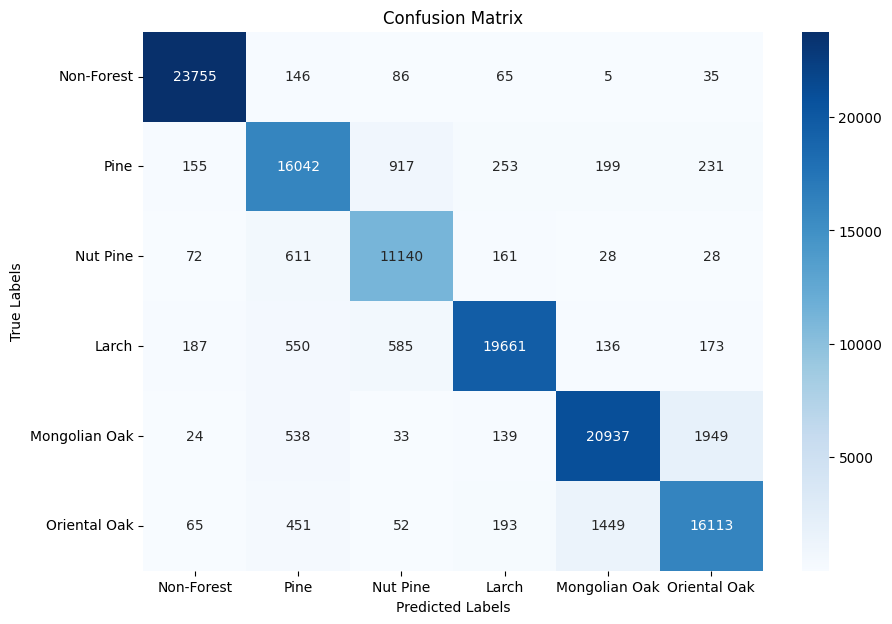

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.979     0.986     0.983     24092
         Pine      0.875     0.901     0.888     17797
     Nut Pine      0.869     0.925     0.896     12040
        Larch      0.960     0.923     0.942     21292
Mongolian Oak      0.920     0.886     0.903     23620
 Oriental Oak      0.870     0.879     0.874     18323

     accuracy                          0.919    117164
    macro avg      0.912     0.917     0.914    117164
 weighted avg      0.920     0.919     0.919    117164

validation data


Evaluation Progress: 100%|██████████| 1159/1159 [00:41<00:00, 28.09it/s]


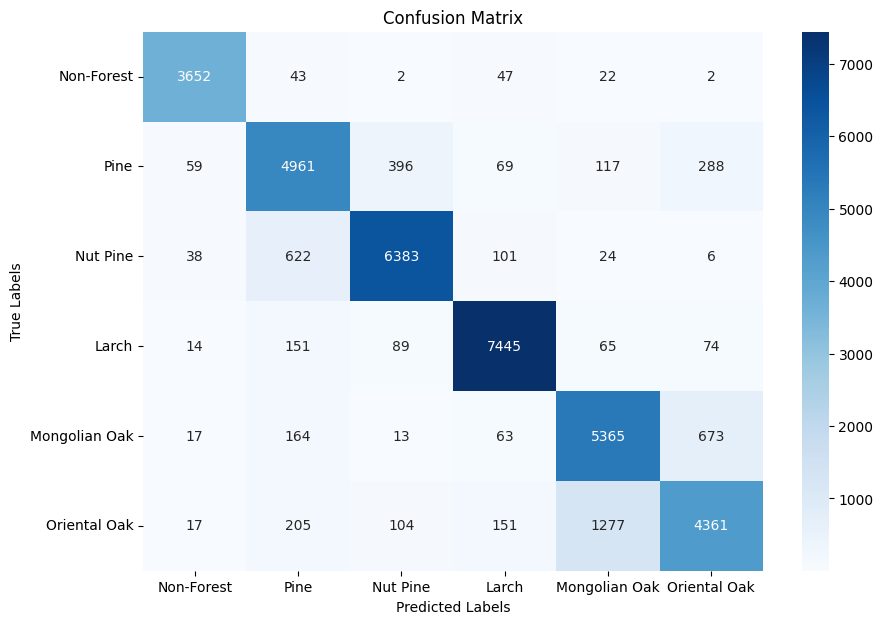

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.962     0.969     0.965      3768
         Pine      0.807     0.842     0.824      5890
     Nut Pine      0.914     0.890     0.901      7174
        Larch      0.945     0.950     0.948      7838
Mongolian Oak      0.781     0.852     0.815      6295
 Oriental Oak      0.807     0.713     0.757      6115

     accuracy                          0.868     37080
    macro avg      0.869     0.869     0.869     37080
 weighted avg      0.868     0.868     0.867     37080

Training with patch size: 7


Epoch 1/15 - Validation: 100%|██████████| 1159/1159 [01:11<00:00, 16.29it/s]



Epoch [1/15], Train Loss: 0.5084, Train Accuracy: 80.82%, Val Loss: 0.8787, Val Accuracy: 71.53%



Epoch 2/15 - Validation: 100%|██████████| 1159/1159 [01:12<00:00, 16.01it/s]



Epoch [2/15], Train Loss: 0.3884, Train Accuracy: 85.51%, Val Loss: 0.6013, Val Accuracy: 77.98%



...

Epoch 14/15 - Validation: 100%|██████████| 1159/1159 [01:09<00:00, 16.60it/s]



Epoch [14/15], Train Loss: 0.1933, Train Accuracy: 92.89%, Val Loss: 0.6447, Val Accuracy: 81.38%



Epoch 15/15 - Validation: 100%|██████████| 1159/1159 [01:08<00:00, 16.81it/s]



Epoch [15/15], Train Loss: 0.1870, Train Accuracy: 93.17%, Val Loss: 0.6001, Val Accuracy: 83.70%

train data


Evaluation Progress: 100%|██████████| 3662/3662 [03:39<00:00, 16.70it/s]


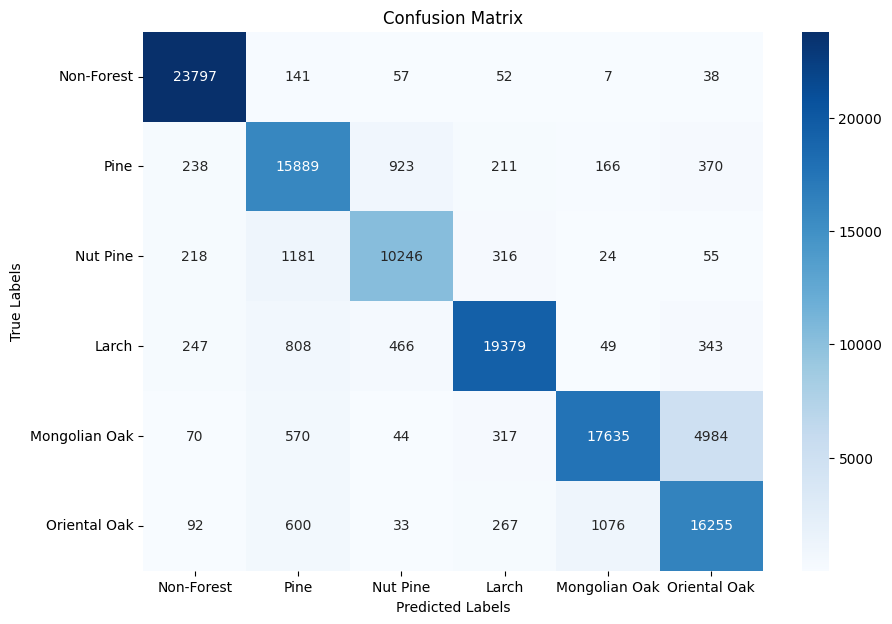

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.965     0.988     0.976     24092
         Pine      0.828     0.893     0.859     17797
     Nut Pine      0.871     0.851     0.861     12040
        Larch      0.943     0.910     0.926     21292
Mongolian Oak      0.930     0.747     0.828     23620
 Oriental Oak      0.737     0.887     0.805     18323

     accuracy                          0.881    117164
    macro avg      0.879     0.879     0.876    117164
 weighted avg      0.888     0.881     0.881    117164

validation data


Evaluation Progress: 100%|██████████| 1159/1159 [01:09<00:00, 16.70it/s]


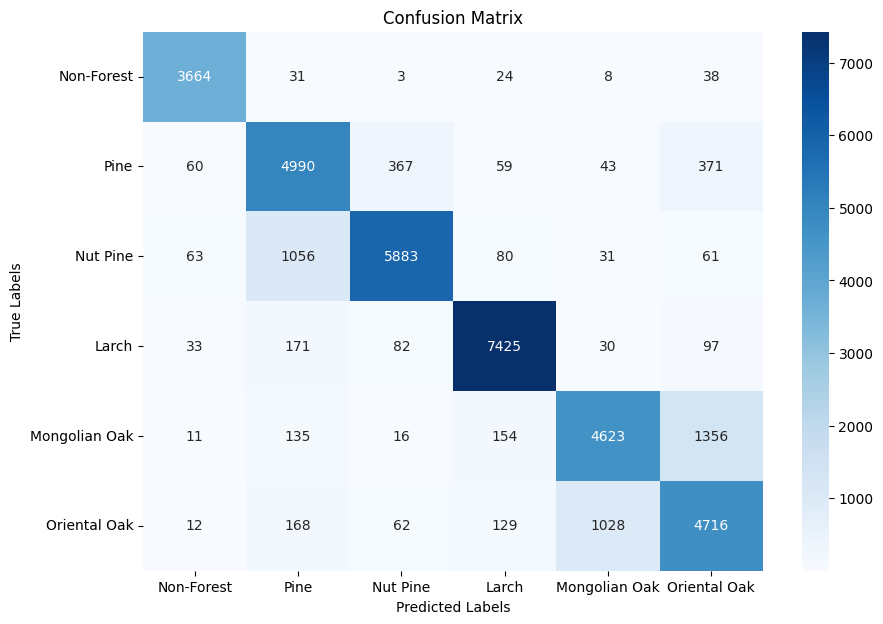

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.953     0.972     0.963      3768
         Pine      0.762     0.847     0.802      5890
     Nut Pine      0.917     0.820     0.866      7174
        Larch      0.943     0.947     0.945      7838
Mongolian Oak      0.802     0.734     0.767      6295
 Oriental Oak      0.710     0.771     0.740      6115

     accuracy                          0.844     37080
    macro avg      0.848     0.849     0.847     37080
 weighted avg      0.848     0.844     0.845     37080

Training with patch size: 9


Epoch 1/15 - Validation: 100%|██████████| 1159/1159 [01:37<00:00, 11.93it/s]



Epoch [1/15], Train Loss: 0.4919, Train Accuracy: 81.44%, Val Loss: 0.5424, Val Accuracy: 81.87%



Epoch 2/15 - Validation: 100%|██████████| 1159/1159 [01:37<00:00, 11.94it/s]



Epoch [2/15], Train Loss: 0.3658, Train Accuracy: 86.36%, Val Loss: 0.7241, Val Accuracy: 79.60%



...

Epoch 14/15 - Validation: 100%|██████████| 1159/1159 [01:37<00:00, 11.90it/s]



Epoch [14/15], Train Loss: 0.1718, Train Accuracy: 93.74%, Val Loss: 0.6116, Val Accuracy: 83.45%



Epoch 15/15 - Validation: 100%|██████████| 1159/1159 [01:38<00:00, 11.79it/s]



Epoch [15/15], Train Loss: 0.1661, Train Accuracy: 94.02%, Val Loss: 0.5072, Val Accuracy: 85.96%

train data


Evaluation Progress: 100%|██████████| 3662/3662 [05:14<00:00, 11.64it/s]


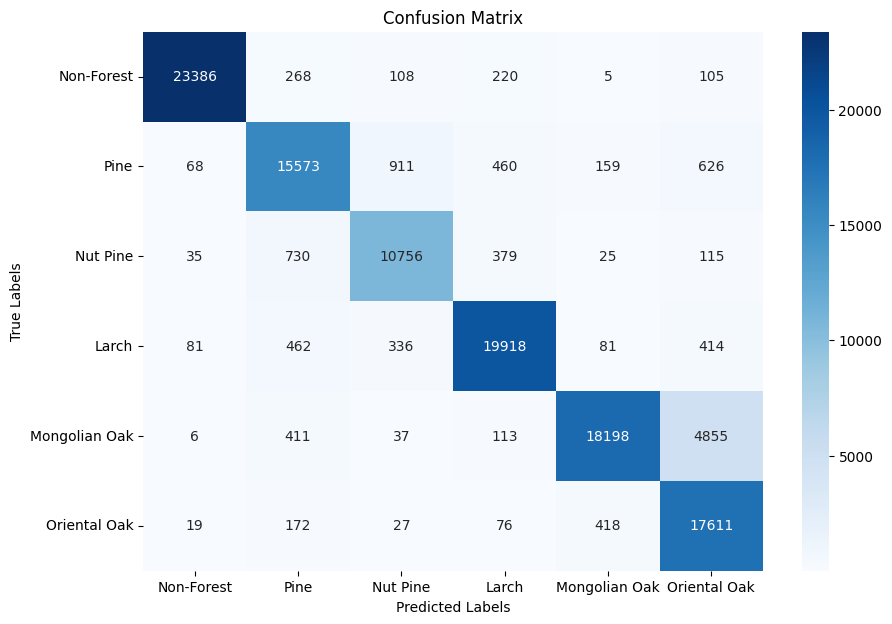

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.991     0.971     0.981     24092
         Pine      0.884     0.875     0.880     17797
     Nut Pine      0.883     0.893     0.888     12040
        Larch      0.941     0.935     0.938     21292
Mongolian Oak      0.964     0.770     0.856     23620
 Oriental Oak      0.742     0.961     0.838     18323

     accuracy                          0.900    117164
    macro avg      0.901     0.901     0.897    117164
 weighted avg      0.910     0.900     0.901    117164

validation data


Evaluation Progress: 100%|██████████| 1159/1159 [01:37<00:00, 11.94it/s]


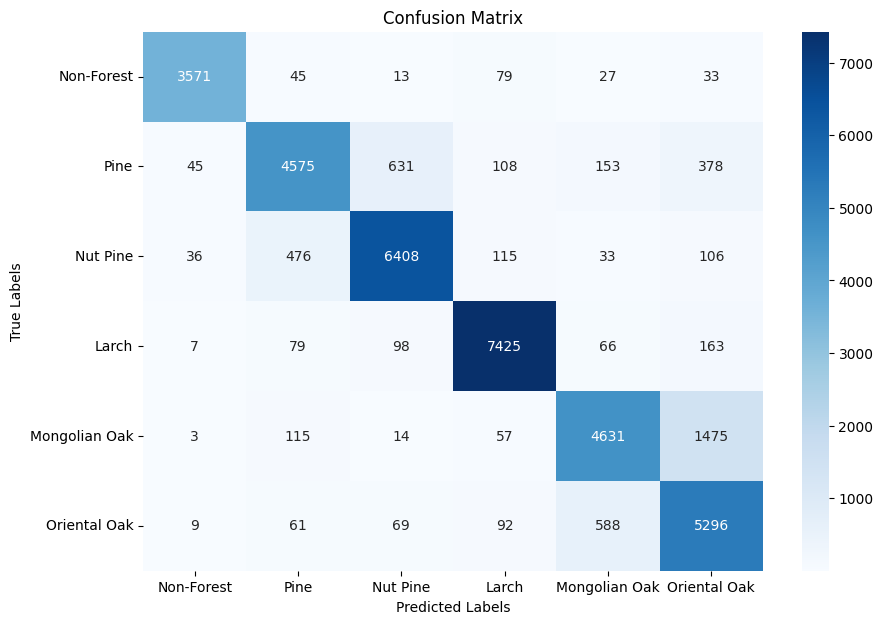

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.973     0.948     0.960      3768
         Pine      0.855     0.777     0.814      5890
     Nut Pine      0.886     0.893     0.890      7174
        Larch      0.943     0.947     0.945      7838
Mongolian Oak      0.842     0.736     0.785      6295
 Oriental Oak      0.711     0.866     0.781      6115

     accuracy                          0.860     37080
    macro avg      0.868     0.861     0.862     37080
 weighted avg      0.866     0.860     0.861     37080

Training with patch size: 11


Epoch 1/15 - Validation: 100%|██████████| 1155/1155 [02:15<00:00,  8.54it/s]



Epoch [1/15], Train Loss: 0.5045, Train Accuracy: 81.05%, Val Loss: 0.6483, Val Accuracy: 77.60%



Epoch 2/15 - Validation: 100%|██████████| 1155/1155 [02:01<00:00,  9.49it/s]



Epoch [2/15], Train Loss: 0.3690, Train Accuracy: 86.28%, Val Loss: 0.7429, Val Accuracy: 77.35%



...

Epoch 14/15 - Validation: 100%|██████████| 1155/1155 [02:24<00:00,  7.99it/s]



Epoch [14/15], Train Loss: 0.1696, Train Accuracy: 93.83%, Val Loss: 0.7558, Val Accuracy: 84.31%



Epoch 15/15 - Validation: 100%|██████████| 1155/1155 [02:27<00:00,  7.83it/s]



Epoch [15/15], Train Loss: 0.1642, Train Accuracy: 94.05%, Val Loss: 0.6285, Val Accuracy: 85.74%

train data


Evaluation Progress: 100%|██████████| 3640/3640 [07:34<00:00,  8.00it/s]


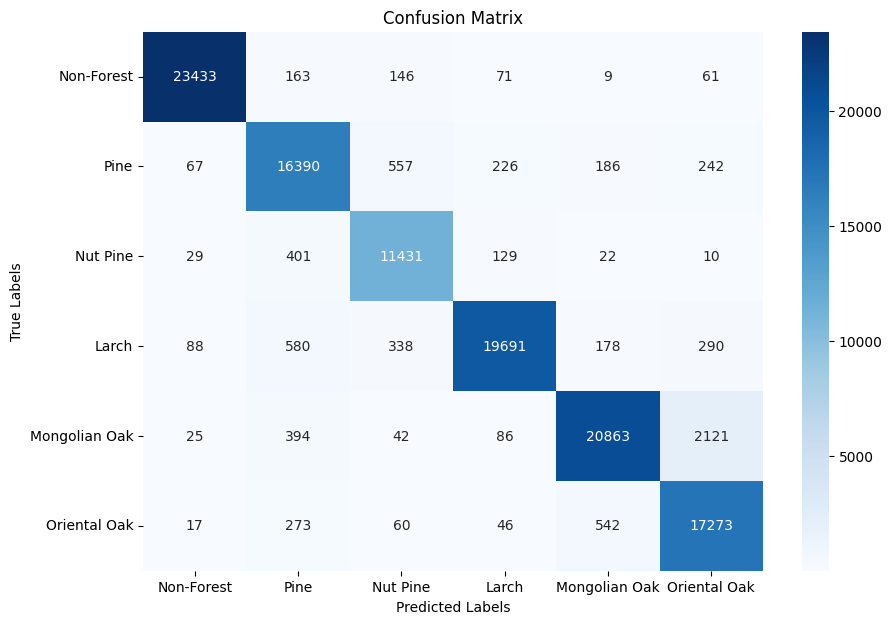

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.990     0.981     0.986     23883
         Pine      0.900     0.928     0.914     17668
     Nut Pine      0.909     0.951     0.930     12022
        Larch      0.972     0.930     0.951     21165
Mongolian Oak      0.957     0.887     0.920     23531
 Oriental Oak      0.864     0.948     0.904     18211

     accuracy                          0.936    116480
    macro avg      0.932     0.938     0.934    116480
 weighted avg      0.939     0.936     0.937    116480

validation data


Evaluation Progress: 100%|██████████| 1155/1155 [02:24<00:00,  7.98it/s]


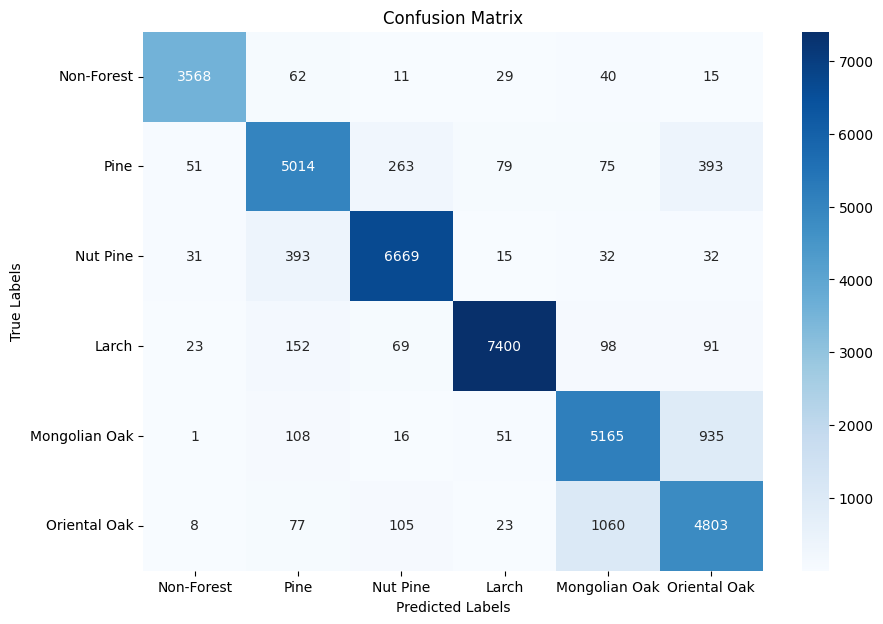

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.969     0.958     0.963      3725
         Pine      0.864     0.853     0.858      5875
     Nut Pine      0.935     0.930     0.932      7172
        Larch      0.974     0.945     0.959      7833
Mongolian Oak      0.798     0.823     0.810      6276
 Oriental Oak      0.766     0.790     0.778      6076

     accuracy                          0.883     36957
    macro avg      0.884     0.883     0.884     36957
 weighted avg      0.884     0.883     0.883     36957



In [12]:
patch_sizes = [5, 7, 9, 11]

# 전체 실행
for patch_size in patch_sizes:
    train_dataset, val_dataset = create_datasets(patch_size)
    train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)
    train_and_evaluate(patch_size, train_loader, val_loader, num_epochs=15)